# Note that this project is meant to be executed in R

![running heart rate](run31.png)

## 📖 The Background
Millions of people develop some sort of heart disease every year, and heart disease is the biggest killer of both men and women in the United States and around the world. Statistical analysis has identified many risk factors associated with heart disease, such as age, blood pressure, total cholesterol, diabetes, hypertension, family history of heart disease, obesity, lack of physical exercise, and more.

In this project, you will run statistical tests and models using the Cleveland heart disease dataset to assess one particular factor -- the maximum heart rate one can achieve during exercise and how it is associated with a higher likelihood of getting heart disease.

Examining how heart rate responds to exercise along with other factors such as age, gender, the maximum heart rate achieved may reveal abnormalities that could be indicative of heart disease. Let's find out more!

## 💾 The Data
Available on `Cleveland_hd.csv`
| Column     | Type | Description              |
|------------|------|--------------------------|
|`age` | continuous | age in years | 
|`sex` | discrete | 0=female 1=male |
|`cp`| discrete | chest pain type: 1=typical angina, 2=atypical angina, 3=non-anginal pain, 4=asymptom |
|`trestbps`| continuous | resting blood pressure (in mm Hg) |
|`chol`| continuous | serum cholesterol in mg/dl |
|`fbs`| discrete | fasting blood sugar>120 mg/dl: 1=true 0=False |
|`restecg`| discrete | result of electrocardiogram while at rest are represented in 3 distinct values 0=Normal 1=having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) 2=showing probable or definite left ventricular hypertrophy Estes' criteria (Nominal) |
|`thalach`| continuous | maximum heart rate achieved |
|`exang`| discrete | exercise induced angina: 1=yes 0=no |
|`oldpeak`| continuous | depression induced by exercise relative to rest |
|`slope`| discrete | the slope of the peak exercise segment: 1=up sloping 2=flat, 3=down sloping
|`ca`| continuous | number of major vessels colored by fluoroscopy that ranged between 0 and 3 |
|`thal`| discrete | 3=normal 6=fixed defect 7=reversible defect |
|`class`| discrete | diagnosis classes: 0=no presence 1=minor indicators for heart disease 2=>1 3=>2 4=major indicators for heart disease|

# Objectives
1) Manipulate the data and use statistical tests to see which predictors are related to heart disease as indicated by the `class` column. Adjust the `class` column to be binary where `0` indicates no heart disease and `1` represents the presence of heart disease. Save the three features with the highest significance to a list called `highly_significant`.
2) Fit a model using your highly significant features to predict the likelihood of heart disease, adjusting the results to be a binary outcome for probabilities greater than 0.5. Calculate and save the following model metrics: accuracy as a numeric variable `accuracy`, and the confusion matrix as `confusion`.

----------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------

In [85]:
# Load the necessary packages
library(tidyverse)
library(yardstick)
library(Metrics)

# Load the data
hd_data_orig <- read.csv("Cleveland_hd.csv")

# Inspect the first five rows
head(hd_data_orig, 5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>
1,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
3,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


# Analysis I
- Manipulate the data and use statistical tests to see which predictors are related to heart disease as indicated by the class column. Adjust the class column to be binary where 0 indicates no heart disease and 1 represents the presence of heart disease. Save the three features with the highest significance to a list called highly_significant.

For categorical variables, use `chisq.test()` to determine if heart disease (`class`) is independent or not. For numerical variables, use `t.test()` to determine if there’s a difference in the means of these variables between people with & without heart disease.

Beforehand, the `class` variable needs to be altered to a binary variable rather than a discrete variable because there should only be two outcomes when predicting this variable.

In [86]:
#Alter the 'class' variable to be binary; values of 1+ should be changed to 1
hd_data <- hd_data_orig %>%
    mutate(hd = ifelse(class >= 1, 1, 0))

In [87]:
chisq.test(hd_data$hd, hd_data$sex)


	Pearson's Chi-squared test with Yates' continuity correction

data:  hd_data$hd and hd_data$sex
X-squared = 22.043, df = 1, p-value = 2.667e-06


In [88]:
#Use statistical tests to determine which features are most related to 'class'
#CATEGORICAL -- chi-square test
chisq_test_sex <- chisq.test(hd_data$sex, hd_data$hd)
chisq_test_cp <- chisq.test(hd_data$cp, hd_data$hd)
chisq_test_fbs <- chisq.test(hd_data$fbs, hd_data$hd)
chisq_test_restecg <- chisq.test(hd_data$restecg, hd_data$hd)
chisq_test_exang <- chisq.test(hd_data$exang, hd_data$hd)
chisq_test_slope <- chisq.test(hd_data$slope, hd_data$hd)
chisq_test_thal <- chisq.test(hd_data$thal, hd_data$hd)

#compile the results into a dataframe
chisq_test_df <- data.frame(Var = c("sex","cp","fbs","restecg","exang","slope","thal"), Test="Chi-Sq", P_Val = c(chisq_test_sex$p.value, chisq_test_cp$p.value, chisq_test_fbs$p.value, chisq_test_restecg$p.value, chisq_test_exang$p.value, chisq_test_slope$p.value, chisq_test_thal$p.value))

#NUMERICAL -- t-test
ttest_age <- t.test(age ~ hd, data=hd_data)
ttest_trestbps <- t.test(trestbps ~ hd, data=hd_data)
ttest_chol <- t.test(chol ~ hd, data=hd_data)
ttest_thalach <- t.test(thalach ~ hd, data=hd_data)
ttest_oldpeak <- t.test(oldpeak ~ hd, data=hd_data)
ttest_ca <- t.test(ca ~ hd, data=hd_data)

#compile the results into a dataframe
ttest_df <- data.frame(Var = c("age","trestbps","chol","thalach","oldpeak","ca"), Test="T-Test", P_Val = c(ttest_age$p.value, ttest_trestbps$p.value, ttest_chol$p.value, ttest_thalach$p.value, ttest_oldpeak$p.value, ttest_ca$p.value))

Warning message in chisq.test(hd_data$restecg, hd_data$hd):
“Chi-squared approximation may be incorrect”


In [89]:
#merge the 2 datasets
test_results <- chisq_test_df %>%
    bind_rows(ttest_df) %>%
    arrange(P_Val)
test_results

#save the 3 features with the highest significance
highly_significant <- list("thal","cp","ca")
highly_significant

Var,Test,P_Val
<chr>,<chr>,<dbl>
thal,Chi-Sq,8.201820e-19
cp,Chi-Sq,1.251711e-17
ca,T-Test,1.144509e-15
thalach,T-Test,9.106166e-14
exang,Chi-Sq,1.413788e-13
oldpeak,T-Test,2.195175e-13
slope,Chi-Sq,1.142885e-10
sex,Chi-Sq,2.666712e-06
age,T-Test,7.061439e-05


[[1]]
[1] "thal"

[[2]]
[1] "cp"

[[3]]
[1] "ca"

# Analysis II
- Fit a model using your highly significant features to predict the likelihood of heart disease, adjusting the results to be a binary outcome for probabilities greater than 0.5. Calculate and save the following model metrics: `accuracy` as a numeric variable accuracy, and the confusion matrix as `confusion`.

Given that the variable being predicted is binary, a logistic regression is appropriate. Recall that the 3 most significant features are `thal`, `cp`, & `ca`.

In [104]:
#Create the Logistic Regression model
logreg_model <- glm(hd ~ thal + cp + ca, data=hd_data, family="binomial")
#logreg_model <- glm(hd ~ age + sex + thalach, data=hd_data, family="binomial")

#retrieve the model summary
summary(logreg_model)


Call:
glm(formula = hd ~ thal + cp + ca, family = "binomial", data = hd_data)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -5.79751    0.69821  -8.303  < 2e-16 ***
thal         0.55174    0.08267   6.674 2.49e-11 ***
cp           0.72735    0.16949   4.292 1.77e-05 ***
ca           1.14989    0.20976   5.482 4.21e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 409.95  on 296  degrees of freedom
Residual deviance: 252.65  on 293  degrees of freedom
  (6 observations deleted due to missingness)
AIC: 260.65

Number of Fisher Scoring iterations: 5


In [105]:
#Cast predictions & ensure outcomes are binary; 0.5+ = 1, otherwise = 0
pred <- predict(logreg_model, newdata=hd_data, type="response")
#append the predictions to the dataset
hd_data$pred <- ifelse(pred >= 0.5, 1, 0)

In [109]:
#mean(hd_data$pred)
    # -> <NA>
#sum(is.na(hd_data$pred))
    # -> 6
#mean(hd_data$pred, na.rm=TRUE)
    # -> ~0.434
#mean(na.omit(hd_data$pred))
    # -> ~0.434

[1] 0.4343434

In [111]:
#Calculate model metrics
accuracy <- accuracy(hd_data$hd, na.omit(hd_data$pred))
#accuracy <- mean(pred_II == hd_data$class)
confusion <- conf_mat(table(hd_data$hd, hd_data$pred))
print(accuracy)
print(confusion)

Warning message in actual != predicted:
“longer object length is not a multiple of shorter object length”


[1] 0.6369637
   
      0   1
  0 135  25
  1  33 104


----------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------------------------------

# DATACAMP SOLUTION

In [95]:
# Use statistical tests to check which features impact heart disease
# Check the sex variable
hd_sex_SOL <- chisq.test(hd_data$sex, hd_data$hd)
print(hd_sex_SOL)

# Check the age variable
hd_age_SOL <- t.test(hd_data$age ~ hd_data$hd)
print(hd_age_SOL)

# Check the thalach variable
hd_heartrate_SOL <- t.test(hd_data$thalach ~ hd_data$hd)
print(hd_heartrate_SOL)

# Save the highly signficant features to a list
highly_significant_SOL <- list("age", "sex", "thalach")


	Pearson's Chi-squared test with Yates' continuity correction

data:  hd_data$sex and hd_data$hd
X-squared = 22.043, df = 1, p-value = 2.667e-06


	Welch Two Sample t-test

data:  hd_data$age by hd_data$hd
t = -4.0303, df = 300.93, p-value = 7.061e-05
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -6.013385 -2.067682
sample estimates:
mean in group 0 mean in group 1 
       52.58537        56.62590 


	Welch Two Sample t-test

data:  hd_data$thalach by hd_data$hd
t = 7.8579, df = 272.27, p-value = 9.106e-14
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 14.32900 23.90912
sample estimates:
mean in group 0 mean in group 1 
        158.378         139.259 



Warning message:
“The following aesthetics were dropped during statistical transformation: fill.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


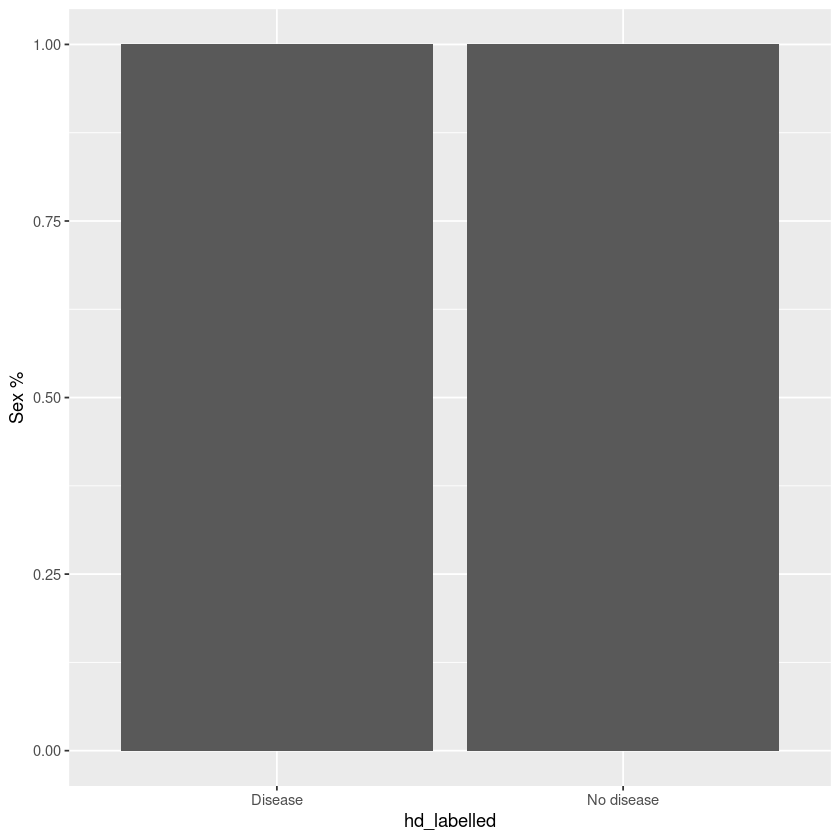

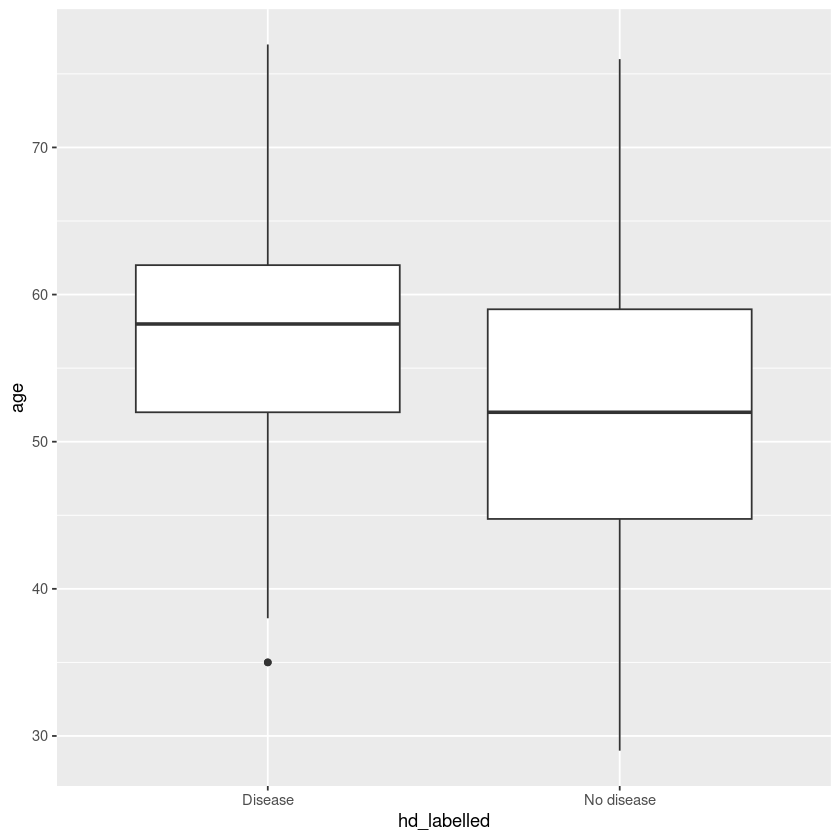

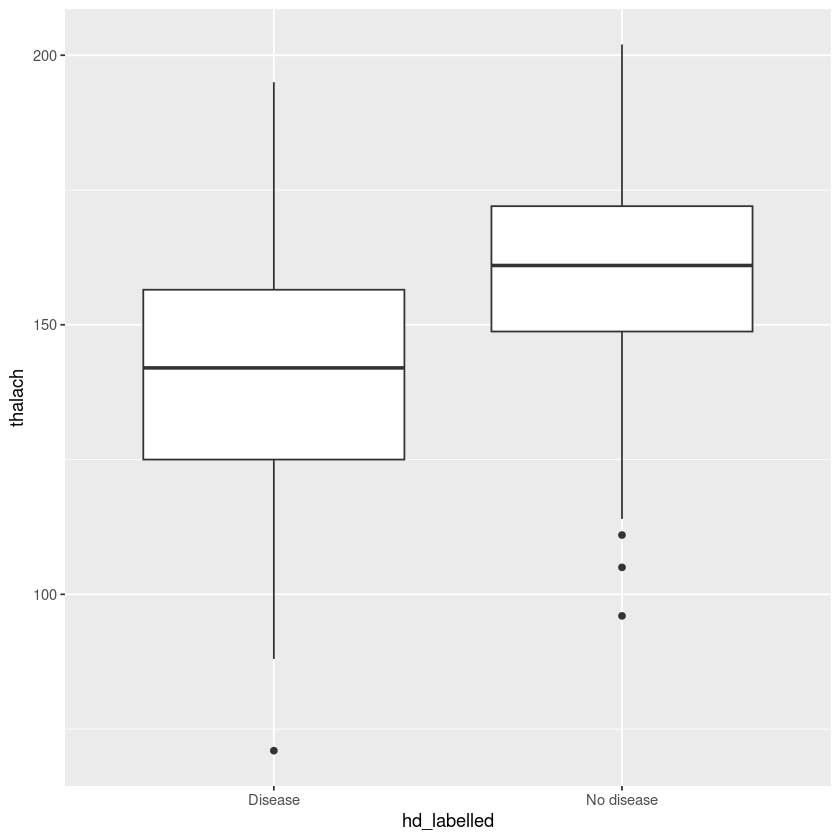

In [96]:
# Optional: explore the associations graphically
# Optional: recode the binary heart disease feature to be labelled
hd_data_mod <- hd_data %>% mutate(hd_labelled = ifelse(hd == 0, "No disease", "Disease"))

# Optional: visualize the sex associations
ggplot(data = hd_data_mod, aes(x = hd_labelled, fill = sex)) + geom_bar(position = "fill") + ylab("Sex %")

# Optional: visualize the age associations
ggplot(data = hd_data_mod, aes(x = hd_labelled, y = age)) + geom_boxplot()

# Optional: visualize the thalach associations
ggplot(data = hd_data_mod, aes(x = hd_labelled, y = thalach)) + geom_boxplot()

In [97]:
# Build a model to predict heart disease using the significant features as predictors
model_SOL <- glm(data = hd_data, hd ~ age + sex + thalach, family = "binomial" )

# Extract the model summary
summary(model_SOL)

# Predict the probability of heart disease
pred_prob_SOL <- predict(model_SOL, hd_data, type="response")

# Create a decision rule using probability 0.5 as cutoff and save the predicted decision into the main data frame
hd_data$pred_hd_SOL <- ifelse(pred_prob_SOL >= 0.5, 1, 0)

# Calculate and print the accuracy score
accuracy_SOL <- accuracy(hd_data$hd, hd_data$pred_hd_SOL)
print(paste("Accuracy=", accuracy_SOL))

# Calculate and print the confusion matrix
confusion_SOL <- conf_mat(table(hd_data$hd, hd_data$pred_hd_SOL))
confusion_SOL


Call:
glm(formula = hd ~ age + sex + thalach, family = "binomial", 
    data = hd_data)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept)  3.111610   1.607466   1.936   0.0529 .  
age          0.031886   0.016440   1.940   0.0524 .  
sex          1.491902   0.307193   4.857 1.19e-06 ***
thalach     -0.040541   0.007073  -5.732 9.93e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 417.98  on 302  degrees of freedom
Residual deviance: 332.85  on 299  degrees of freedom
AIC: 340.85

Number of Fisher Scoring iterations: 4


[1] "Accuracy= 0.70957095709571"


   
      0   1
  0 122  42
  1  46  93